## Using JSON files and Dataframe from 01_data_collection notebook

In [1]:
import json
import pandas as pd

# Loading json files
with open("../data/raw/NCD_BMI_30C.json") as f:
    obesity_adult = json.load(f)["value"]

with open("../data/raw/NCD_BMI_PLUS2C.json") as f:
    obesity_child = json.load(f)["value"]

with open("../data/raw/NCD_BMI_18C.json") as f:
    malnutrition_adult = json.load(f)["value"]

with open("../data/raw/NCD_BMI_MINUS2C.json") as f:
    malnutrition_child = json.load(f)["value"]

df_obesity_adult = pd.DataFrame(obesity_adult)
df_obesity_child = pd.DataFrame(obesity_child)
df_malnutrition_adult = pd.DataFrame(malnutrition_adult)
df_malnutrition_child = pd.DataFrame(malnutrition_child)

#creating age_group and category columns in dataframes
df_obesity_adult["Age_Group"] = "Adult"
df_obesity_child["Age_Group"] = "Child/Adolescent"
df_malnutrition_adult["Age_Group"] = "Adult"
df_malnutrition_child["Age_Group"] = "Child/Adolescent"

df_obesity_adult["_category"] = "obesity"
df_obesity_child["_category"] = "obesity"
df_malnutrition_adult["_category"] = "malnutrition"
df_malnutrition_child["_category"] = "malnutrition"

#Recreating 2 combined dataframes
df_obesity = pd.concat(
    [df_obesity_adult, df_obesity_child],
    ignore_index=True
)

df_malnutrition = pd.concat(
    [df_malnutrition_adult, df_malnutrition_child],
    ignore_index=True
)
df_obesity = df_obesity[df_obesity["TimeDim"].between(2012,2022)]
df_malnutrition = df_malnutrition[df_malnutrition["TimeDim"].between(2012,2022)]

In [2]:
import pandas as pd
import pycountry

## Column selcetion and renaming

In [3]:
COLS_KEEP=["ParentLocation","Dim1","TimeDim","Low","High","NumericValue","SpatialDim","Age_Group"]
RENAME = {
    "TimeDim":      "Year",
    "Dim1":         "Gender",
    "NumericValue": "Mean_Estimate",
    "Low":          "LowerBound",
    "High":         "UpperBound",
    "ParentLocation":"Region",
    "SpatialDim":   "Country",
}

## Pycountry converter

In [4]:
SPECIAL_CASES = {
    "GLOBAL":"Global",
    "WB_LMI":"Low & Middle Income",
    "WB_HI":"High Income",
    "WB_LI":"Low Income",
    "EMR":"Eastern Mediterranean Region",
    "EUR":"Europe",
    "AFR":"Africa",
    "SEAR":"South-East Asia Region",
    "WPR":"Western Pacific Region",
    "AMR":"Americas Region",
    "WB_UMI":"Upper Middle Income",
}

def code_to_country(code):
    if pd.isna(code): return None
    code = str(code).strip().upper()
    if code in SPECIAL_CASES:
        return SPECIAL_CASES[code]
    try:
        return pycountry.countries.get(alpha_3=code).name
    except AttributeError:
        return code   # keep original if not found

In [5]:
def clean_df(df, label_col, level_fn):
    df = df[COLS_KEEP].copy()
    df = df.rename(columns=RENAME)                         #Schema standardization


    # Standardise gender
    df["Gender"] = df["Gender"].map({
        "SEX_MLE":"Male","SEX_FMLE":"Female","SEX_BTSX":"Both"}).fillna("Both")                                       #Categorical normalization

    # Year as int, filter 2012-2022
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
    df = df[df["Year"].between(2012, 2022)].reset_index(drop=True)

    
    # Convert country codes
    df["Country"] = df["Country"].apply(code_to_country)    #Element wise transformation


    # Ensure numerics
    for col in ["Mean_Estimate","LowerBound","UpperBound"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")


    # Feature engineering
    df["CI_Width"] = (df["UpperBound"] - df["LowerBound"]).round(2)
    df[label_col] = df["Mean_Estimate"].apply(level_fn)     # Classififcation/Categorization
    df = df.dropna(subset=["Mean_Estimate","Country"])
    return df

def obesity_level(v):
    if v >= 30: return "High"
    if v >= 25: return "Moderate"
    return "Low"

def malnutrition_level(v):
    if v >= 20: return "High"
    if v >= 10: return "Moderate"
    return "Low"

df_obesity     = clean_df(df_obesity,"Obesity_Level",obesity_level)
df_malnutrition= clean_df(df_malnutrition,"Malnutrition_Level",malnutrition_level)

# Save processed
df_obesity.to_csv("../data/processed/obesity_clean.csv", index=False)
df_malnutrition.to_csv("../data/processed/malnutrition_clean.csv", index=False)

print("Obesity shape:",     df_obesity.shape)
print("Malnutrition shape:",df_malnutrition.shape)
print(df_obesity.dtypes)

Obesity shape: (27720, 10)
Malnutrition shape: (27720, 10)
Region            object
Gender            object
Year               Int64
LowerBound       float64
UpperBound       float64
Mean_Estimate    float64
Country           object
Age_Group         object
CI_Width         float64
Obesity_Level     object
dtype: object


## EDA with Python

In [6]:
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns, matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = "png"

# --- Basic health check ---
print(df_obesity.shape, df_obesity.isnull().sum())
print(df_obesity["Gender"].value_counts())
print(df_obesity["Region"].value_counts())
print(df_obesity["Obesity_Level"].value_counts())
print(df_malnutrition["Malnutrition_Level"].value_counts())

(27720, 10) Region           1452
Gender              0
Year                0
LowerBound          0
UpperBound          0
Mean_Estimate       0
Country             0
Age_Group           0
CI_Width            0
Obesity_Level       0
dtype: int64
Gender
Male      9240
Female    9240
Both      9240
Name: count, dtype: int64
Region
Europe                   6864
Africa                   6204
Americas                 4884
Western Pacific          4092
Eastern Mediterranean    2904
South-East Asia          1320
Name: count, dtype: int64
Obesity_Level
Low         24364
High         1929
Moderate     1427
Name: count, dtype: int64
Malnutrition_Level
Low         23647
Moderate     3571
High          502
Name: count, dtype: int64


# 1. Global average Obesity VS Malnutrition

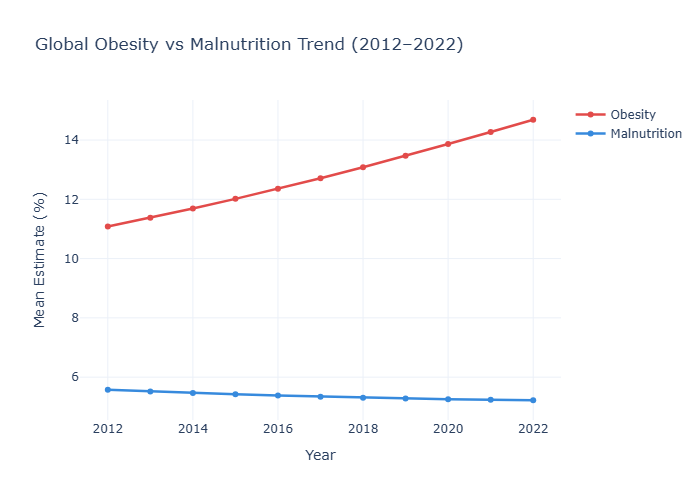

In [7]:
# 1. Global average obesity vs malnutrition over time (dual-line)
ob_yr = df_obesity[df_obesity["Gender"]=="Both"].groupby("Year")["Mean_Estimate"].mean().reset_index()
mn_yr = df_malnutrition[df_malnutrition["Gender"]=="Both"].groupby("Year")["Mean_Estimate"].mean().reset_index()
fig = go.Figure()
fig.add_scatter(x=ob_yr.Year, y=ob_yr.Mean_Estimate, name="Obesity", line=dict(color="#E24B4A", width=2.5))
fig.add_scatter(x=mn_yr.Year, y=mn_yr.Mean_Estimate, name="Malnutrition", line=dict(color="#378ADD", width=2.5))
fig.update_layout(title="Global Obesity vs Malnutrition Trend (2012–2022)",
                  xaxis_title="Year", yaxis_title="Mean Estimate (%)", template="plotly_white")
fig.show()

# 2. Top 10 Countries with Obesity

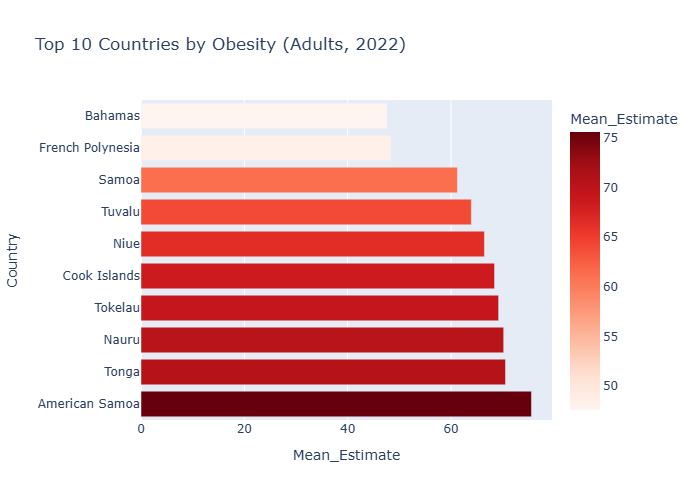

In [8]:
# 2. Top 10 countries by obesity (adults, Both, 2022)
top_ob = (df_obesity[(df_obesity.Year==2022)&(df_obesity.Gender=="Both")&(df_obesity.Age_Group=="Adult")].groupby("Country")["Mean_Estimate"].mean().nlargest(10).reset_index())
fig2 = go.Figure()
fig2 = px.bar(top_ob, x="Mean_Estimate", y="Country", orientation="h",color="Mean_Estimate", color_continuous_scale="Reds",title="Top 10 Countries by Obesity (Adults, 2022)")
fig2.show()


# 3. Top 10 Countries by malnutrition

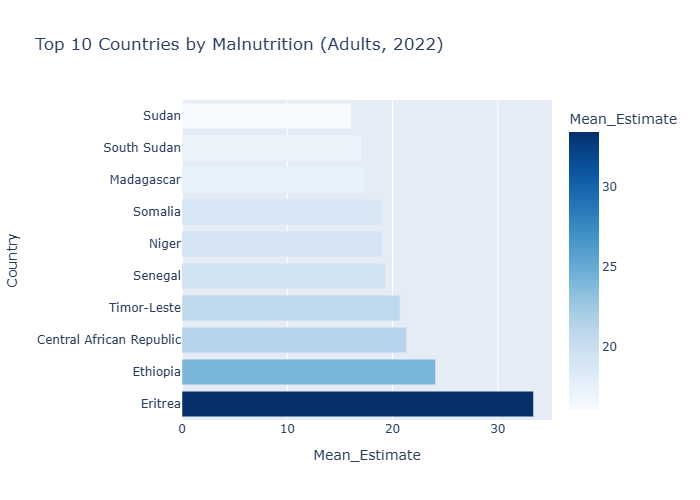

In [9]:
# 3. Top 10 countries by malnutrition
top_mn = (df_malnutrition[(df_malnutrition.Year==2022)&(df_malnutrition.Gender=="Both")&(df_malnutrition.Age_Group=="Adult")].groupby("Country")["Mean_Estimate"].mean().nlargest(10).reset_index())
fig3 = go.Figure()
fig3 = px.bar(top_mn, x="Mean_Estimate", y="Country", orientation="h",color="Mean_Estimate", color_continuous_scale="Blues",title="Top 10 Countries by Malnutrition (Adults, 2022)")
fig3.show()

# 4. Gender gap in Obesity

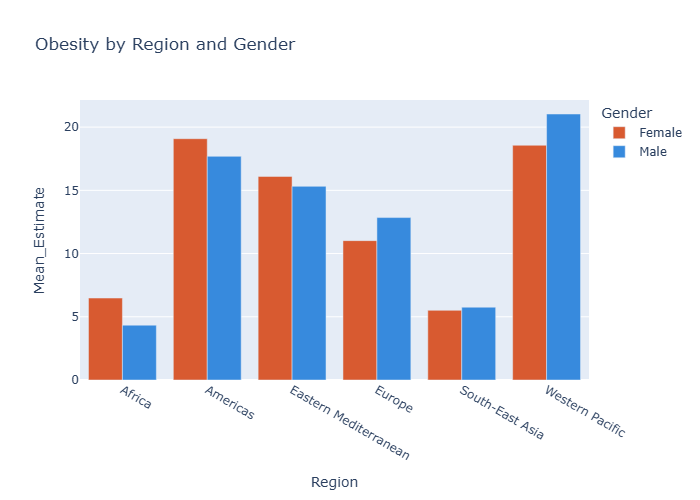

In [10]:
# 4. Gender gap — obesity
gender_ob = (df_obesity[df_obesity.Gender.isin(["Male","Female"])].groupby(["Region","Gender"])["Mean_Estimate"].mean().reset_index())
fig4 = go.Figure()
fig4 = px.bar(gender_ob, x="Region", y="Mean_Estimate", color="Gender",barmode="group", title="Obesity by Region and Gender",color_discrete_map={"Male":"#378ADD","Female":"#D85A30"})
fig4.show()

# 5. CI_Width distribution

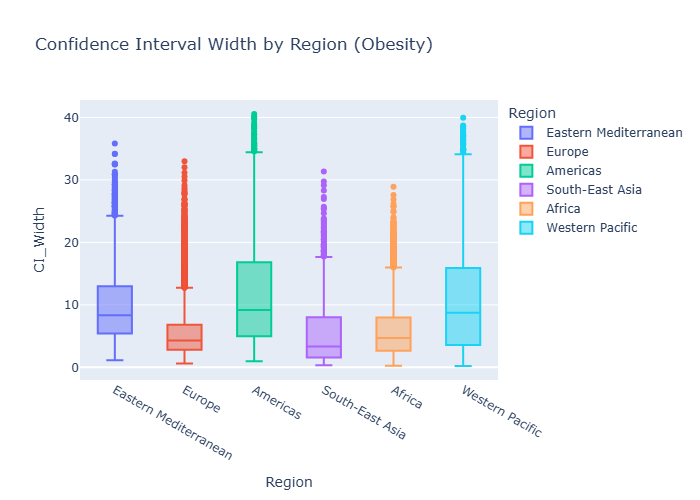

In [11]:
# 5. CI_Width distribution — data reliability
fig5 = go.Figure()
fig5 = px.box(df_obesity, x="Region", y="CI_Width",color="Region",
              title="Confidence Interval Width by Region (Obesity)")
fig5.show()

# 6. Obesity VS Malnutrition scatter per Country

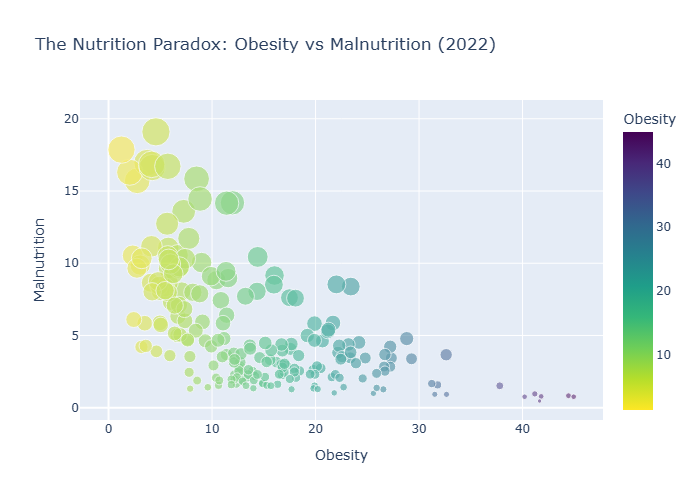

In [12]:
# 6. Obesity vs malnutrition scatter per country (recruiter wow moment)
ob_c = df_obesity[(df_obesity.Gender=="Both")&(df_obesity.Year==2022)].groupby("Country")["Mean_Estimate"].mean().reset_index(name="Obesity")
mn_c = df_malnutrition[(df_malnutrition.Gender=="Both")&(df_malnutrition.Year==2022)].groupby("Country")["Mean_Estimate"].mean().reset_index(name="Malnutrition")
merged = ob_c.merge(mn_c, on="Country")
fig6 = go.Figure()
fig6 = px.scatter(
    merged,
    x="Obesity",
    y="Malnutrition",
    hover_name="Country",
    color="Obesity",
    size="Malnutrition",
    color_continuous_scale="Viridis_r",
    title="The Nutrition Paradox: Obesity vs Malnutrition (2022)"
)
fig6.update_traces(opacity=0.7)
fig6.show()

# 7. Age group Comparison

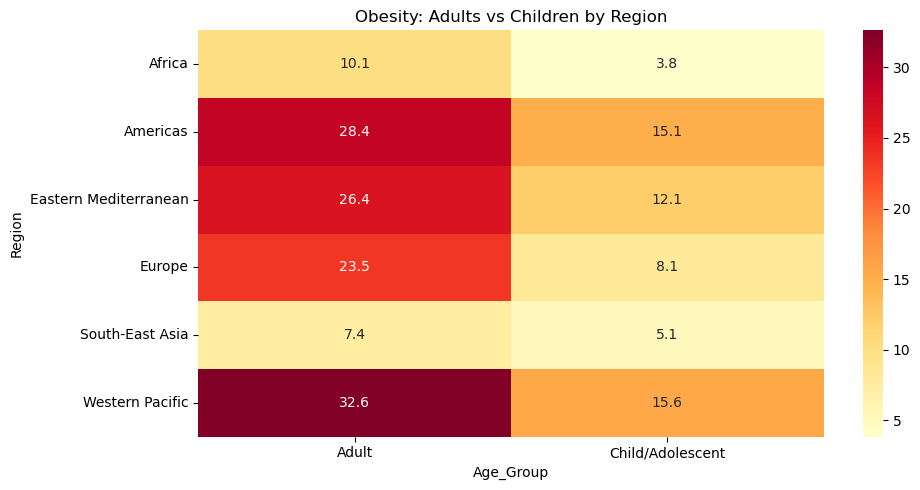

In [13]:
# 7. Age group comparison — heatmap
hm = (df_obesity.groupby(["Region","Age_Group"])["Mean_Estimate"].mean().unstack().fillna(0))
fig7 = go.Figure()
fig7, ax = plt.subplots(figsize=(10,5))
sns.heatmap(hm, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("Obesity: Adults vs Children by Region")
plt.tight_layout(); plt.show()